# **Caso Starbucks: Modelando la Fidelización del Cliente**

Starbucks ha solicitado el desarrollo de un modelo predictivo robusto que permita clasificar a los clientes con mayor probabilidad de convertirse en fieles defensores de la marca. Este modelo debe ser capaz de analizar y segmentar a los usuarios con base en una variedad de factores clave, como el rango de edad, nivel de ingresos, proximidad a las tiendas, y sus evaluaciones sobre aspectos críticos del servicio, como el precio, la calidad de la comida y la atención al cliente.

El enfoque de Starbucks se centra en la utilización de una base de datos comprensiva que capture las características demográficas y de comportamiento de sus clientes. A través de técnicas avanzadas de machine learning, el modelo predictivo buscará patrones que permitan identificar a los consumidores con el mayor potencial de lealtad. Los resultados de este análisis serán fundamentales para personalizar las estrategias de marketing y mejorar la experiencia del cliente, alineándose con el objetivo de Starbucks de construir una base de clientes más sólida y comprometida.

## **Importación de librerías necesarias**

In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from IPython.display import display, Markdown
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from google.colab import data_table
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import statsmodels.api as sm
from sklearn.cluster import KMeans
import warnings

<frozen importlib._bootstrap>:1047: ImportWarning:

_PyDrive2ImportHook.find_spec() not found; falling back to find_module()

<frozen importlib._bootstrap>:1047: ImportWarning:

_PyDriveImportHook.find_spec() not found; falling back to find_module()

<frozen importlib._bootstrap>:1047: ImportWarning:

_GenerativeAIImportHook.find_spec() not found; falling back to find_module()

<frozen importlib._bootstrap>:1047: ImportWarning:

_OpenCVImportHook.find_spec() not found; falling back to find_module()

<frozen importlib._bootstrap>:1047: ImportWarning:

_BokehImportHook.find_spec() not found; falling back to find_module()



## **Funciones utlizadas**

### **Funciones para gráficos**

In [33]:
DARK_BLUE_PALETTE = ["#10451d", "#208b3a", "#25a244", "#4ad66d", "#4ad66d"]

In [42]:
def VisualizacionInicial(df, nombre):

    # Hacer una copia y convertir tipos de datos
    df_vis = df.copy()
    for col in df_vis.select_dtypes(include=['Int64']):
        df_vis[col] = df_vis[col].astype('int64')

    paleta = ["#10451d", "#208b3a", "#25a244", "#4ad66d"]
    fuente = "Inter"
    tamaño_letra = 16
    tamaño_titulo = 18

    # Gráfico circular de tipos de datos
    tipos = df_vis.dtypes.value_counts().reset_index()
    tipos.columns = ['Tipo', 'Cantidad']
    tipos['Tipo'] = tipos['Tipo'].astype(str)

    fig_pie = px.pie(
        tipos,
        values='Cantidad',
        names='Tipo',
        title=f'<b style="font-size:{tamaño_titulo}px">Distribución de Tipos de Datos</b><br><sup>{nombre}</sup>',
        color_discrete_sequence=paleta,
        hole=0.4
    )

    fig_pie.update_traces(
        textposition='inside',
        textinfo='percent+label',
        marker=dict(line=dict(color='white', width=1)),
        textfont_size=tamaño_letra
    )

    fig_pie.update_layout(
        font_family=fuente,
        font_size=tamaño_letra,
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            font=dict(size=tamaño_letra)
        ),
        hoverlabel=dict(
            font_size=tamaño_letra,
            font_family=fuente
        ),
        paper_bgcolor='white',
        plot_bgcolor='white'
    )

    # Gráfico de valores nulos
    nulos = df_vis.isnull().mean().round(4)*100
    nulos = nulos[nulos > 0].reset_index()
    nulos.columns = ['Variable', 'Porcentaje']
    nulos['Porcentaje'] = nulos['Porcentaje'].astype('float64')

    if not nulos.empty:
        fig_nulos = px.bar(
            nulos.sort_values('Porcentaje', ascending=False),
            x='Variable',
            y='Porcentaje',
            title=f'<b style="font-size:{tamaño_titulo}px">Porcentaje de Valores Nulos</b><br><sup>{nombre}</sup>',
            text='Porcentaje',
            color='Porcentaje',
            color_continuous_scale=paleta
        )

        fig_nulos.update_traces(
            texttemplate='%{text:.2f}%',
            textposition='outside',
            marker_line_color='white',
            marker_line_width=1.5,
            textfont_size=tamaño_letra
        )

        fig_nulos.update_layout(
            yaxis_title='Porcentaje de nulos (%)',
            xaxis_title='',
            font_family=fuente,
            font_size=tamaño_letra,
            coloraxis_showscale=False,
            hovermode='x unified',
            paper_bgcolor='white',
            plot_bgcolor='white',
            xaxis=dict(tickfont=dict(size=tamaño_letra)),
            yaxis=dict(tickfont=dict(size=tamaño_letra))
        )

    # Gráfico temporal
    if 'Year' in df_vis.columns:
        temporal = df_vis['Year'].value_counts().sort_index().reset_index()
        temporal.columns = ['Year', 'Conteo']
        temporal['Year'] = temporal['Year'].astype('int64')

        fig_line = px.line(
            temporal,
            x='Year',
            y='Conteo',
            title=f'<b style="font-size:{tamaño_titulo}px">Distribución Temporal</b><br><sup>{nombre}</sup>',
            markers=True,
            color_discrete_sequence=[paleta[0]]
        )

        fig_line.update_traces(
            line_width=3,
            marker=dict(size=10, line=dict(width=2, color='white')),
            textfont_size=tamaño_letra
        )

        fig_line.update_layout(
            xaxis_title='Año',
            yaxis_title='Registros',
            font_family=fuente,
            font_size=tamaño_letra,
            hovermode='x unified',
            paper_bgcolor='white',
            plot_bgcolor='white',
            xaxis=dict(
                tickfont=dict(size=tamaño_letra),
                titlefont=dict(size=tamaño_letra)
            ),
            yaxis=dict(
                tickfont=dict(size=tamaño_letra),
                titlefont=dict(size=tamaño_letra)
            )
        )

    # Mostrar gráficos
    fig_pie.show()

    if not nulos.empty:
        fig_nulos.show()
    else:
        print("\n✅ No hay valores nulos para visualizar")

    if 'Year' in df_vis.columns:
        fig_line.show()
    else:
        print("\nℹ️ No se encontró columna 'Year' para análisis temporal")

In [34]:
def UnivariadoCatg(df):

    warnings.filterwarnings("ignore", category=UserWarning)
    warnings.filterwarnings("ignore", category=FutureWarning)

    ex = ['Timestamp', 'main_purchase', 'promo_source']
    cat = df.select_dtypes(include='object').drop(columns=ex, errors='ignore')

    for c in cat.columns:
        value_counts = cat[c].value_counts()
        n_categories = len(value_counts)

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        sns.countplot(
            data=cat,
            x=c,
            order=value_counts.index,
            palette=DARK_BLUE_PALETTE[:n_categories]
        )
        plt.xticks(rotation=90)
        plt.title(f'Barras - {c}')

        plt.subplot(1, 2, 2)
        value_counts.plot.pie(
            autopct='%1.1f%%',
            colors=DARK_BLUE_PALETTE[:n_categories],
            wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
        )
        plt.ylabel('')
        plt.title(f'Pastel - {c}')

        plt.tight_layout()
        plt.show()

    warnings.filterwarnings("default")

In [35]:
def UnivariateIntegerAnalysis(df):

    warnings.filterwarnings("ignore", category=UserWarning)
    warnings.filterwarnings("ignore", category=FutureWarning)

    exclude = ['Previous Scores']
    int_cols = [col for col in df.select_dtypes(include='int').columns if col not in exclude]

    for col in int_cols:
        print(f'Variable: {col}')
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        order = sorted(df[col].unique())

        sns.countplot(data=df, x=col, ax=axes[0], color=DARK_BLUE_PALETTE[1], order=order)

        sns.boxplot(data=df, x=col, ax=axes[1], color=DARK_BLUE_PALETTE[4])

        axes[0].set_title('Gráfico de barras')
        axes[1].set_title('Boxplot')

        plt.tight_layout()
        plt.show()

    warnings.filterwarnings("default")

### **Otras funciones**

In [7]:
def AnalisisEstructura(df, nombre):

    print(f"🔍 Análisis estructural del dataset: {nombre}")

    # Dimensiones del dataset
    print(f"\n📌 Dimensiones: {df.shape[0]} registros x {df.shape[1]} variables\n")

    # Duplicados
    duplicados = df.duplicated().sum()
    print(f"\n📌 Filas duplicadas: {duplicados} ({duplicados/len(df):.2%})\n")

    # Valores nulos
    nulos = pd.DataFrame({
        'Variable': df.isnull().sum().index,
        'Valores nulos': df.isnull().sum().values,
        '% Nulos': (df.isnull().mean()*100).round(2)
    }).query('`Valores nulos` > 0')

    if not nulos.empty:
        nulos_styled = (nulos.style
                       .set_caption("Variables con valores nulos")
                       .format({'% Nulos': "{:.2f}%"})
                       .background_gradient(subset=['Valores nulos', '% Nulos'], cmap='Purples'))
        display(nulos_styled)
    else:
        print("✅ No se encontraron valores nulos")

    print("")

    # Tipos de variables
    tipos = df.dtypes.reset_index()
    tipos.columns = ['Variable', 'Tipo']
    tipos_styled = (tipos.style
                   .set_caption("Tipos de variables")
                   .background_gradient(cmap='Purples_r')
                   .set_properties(**{'text-align': 'left'}))
    display(tipos_styled)

In [8]:
def ModeImputer(df):
    d = df.copy()
    for c in d.columns:
        if d[c].isnull().sum() > 0:
            m = d[c].mode()[0]
            d[c].fillna(m, inplace=True)
    return d

In [9]:
def CleanSpend(x):
    if isinstance(x, str):
        x = x.replace('$', '').replace('RM', '').lower().strip()
        if '-' in x:
            try:
                a, b = x.split('-')
                return (float(a.strip()) + float(b.strip())) / 2
            except:
                return None
        elif 'around' in x:
            try:
                return float(x.replace('around', '').strip())
            except:
                return None
        elif 'less than' in x:
            try:
                return float(x.replace('less than', '').strip()) - 1
            except:
                return None
        elif 'more than' in x:
            try:
                return float(x.replace('more than', '').strip()) + 1
            except:
                return None
        else:
            try:
                return float(x.strip())
            except:
                return None
    return None

In [10]:
def Indicadores(df):
    f = {
        'Daily': 7, '4-5 times a week': 5, '2-3 times a week': 3,
        'Once a week': 1, '2-3 times a month': 0.5,
        'Once a month': 0.25, 'Less often': 0.1
    }

    df['store_exp'] = df[['rate_ambience', 'rate_wifi', 'rate_service']].mean(axis=1)
    df['value_score'] = (df['rate_quality'] + df['rate_price']) / 2
    df['member_card_bin'] = df['member_card'].apply(lambda x: 1 if 'Yes' in x else 0)
    df['loyal_intent'] = df[['rate_meetup', 'rate_service']].mean(axis=1) + df['member_card_bin']
    return df

In [12]:
def PrepararModelo(df):
    d = df.copy()
    cat = d.select_dtypes(include='object')
    c_usar = [c for c in cat.columns if cat[c].nunique() <= 10 and c != 'loyal']
    d = d.drop(columns=[c for c in cat.columns if c not in c_usar + ['loyal']])
    d = pd.get_dummies(d, columns=c_usar, drop_first=True, dtype=int)
    return d

In [13]:
def ModeloLogistico(df, y='loyal'):
    d = df.copy()
    d[y] = d[y].apply(lambda x: 1 if 'Yes' in x else 0)
    X = d.drop(columns=y)
    X = sm.add_constant(X)
    X = X.loc[:, ~X.columns.duplicated()]
    y = d[y]
    m = sm.Logit(y, X).fit()
    return m

## **Importación de los datos**



In [14]:
# Cargar dataset
url = "https://raw.githubusercontent.com/daramireh/simonBolivarCienciaDatos/main/Starbucks%20satisfactory%20survey.csv"

# Dataset
df = pd.read_csv(url)

## **Análisis Exploratorio de Datos**

In [15]:
display(df.head())

,Timestamp,1. Your Gender,2. Your Age,3. Are you currently....?,4. What is your annual income?,5. How often do you visit Starbucks?,6. How do you usually enjoy Starbucks?,7. How much time do you normally spend during your visit?,8. The nearest Starbucks's outlet to you is...?,9. Do you have Starbucks membership card?,...,"11. On average, how much would you spend at Starbucks per visit?","12. How would you rate the quality of Starbucks compared to other brands (Coffee Bean, Old Town White Coffee..) to be:",13. How would you rate the price range at Starbucks?,14. How important are sales and promotions in your purchase decision?,"15. How would you rate the ambiance at Starbucks? (lighting, music, etc...)",16. You rate the WiFi quality at Starbucks as..,"17. How would you rate the service at Starbucks? (Promptness, friendliness, etc..)",18. How likely you will choose Starbucks for doing business meetings or hangout with friends?,19. How do you come to hear of promotions at Starbucks? Check all that apply.,20. Will you continue buying at Starbucks?
0,2019/10/01 12:38:43 PM,Female,From 20 to 29,Student,"Less than RM25,000",Rarely,Dine in,Between 30 minutes to 1 hour,within 1km,Yes,...,Less than RM20,4,3,5,5,4,4,3,Starbucks Website/Apps;Social Media;Emails;Dea...,Yes
1,2019/10/01 12:38:54 PM,Female,From 20 to 29,Student,"Less than RM25,000",Rarely,Take away,Below 30 minutes,1km - 3km,Yes,...,Less than RM20,4,3,4,4,4,5,2,Social Media;In Store displays,Yes
2,2019/10/01 12:38:56 PM,Male,From 20 to 29,Employed,"Less than RM25,000",Monthly,Dine in,Between 30 minutes to 1 hour,more than 3km,Yes,...,Less than RM20,4,3,4,4,4,4,3,In Store displays;Billboards,Yes
3,2019/10/01 12:39:08 PM,Female,From 20 to 29,Student,"Less than RM25,000",Rarely,Take away,Below 30 minutes,more than 3km,No,...,Less than RM20,2,1,4,3,3,3,3,Through friends and word of mouth,No
4,2019/10/01 12:39:20 PM,Male,From 20 to 29,Student,"Less than RM25,000",Monthly,Take away,Between 30 minutes to 1 hour,1km - 3km,No,...,Around RM20 - RM40,3,3,4,2,2,3,3,Starbucks Website/Apps;Social Media,Yes


En esta vista previa de los datos, se percibe inicialmente que el nombre de las variable es directamente la pregunta en la encuesta de satisfacción, lo que prodría causar inconvenientes en análisis posteriores. Se cuenta con variables como la fecha y hora donde fue respondida la encuesta, datos del cliente como su edad, género, estado, ingresos anuales, etc. Además, datos sumamemente valiosos para Starbucks como frecuencia de visita, duración promedio de esas visitas, si tiene una membresía en la empresa o no, etc.

### **Renombramiento de variables**

Para evitar posibles confusiones y algún error posible adicional en el análisis, se tomó la decisión de renombrar las variables de tal forma que el uso de estas fuese más sencillo. Aquí se presentan las asignaciones:

In [16]:
cols = {
    "1. Your Gender": "gender",
    "2. Your Age": "age",
    "3. Are you currently....?": "status",
    "4. What is your annual income?": "income",
    "5. How often do you visit Starbucks?": "visit_freq",
    "6. How do you usually enjoy Starbucks?": "usage_type",
    "7. How much time do you normally spend during your visit?": "visit_time",
    "8. The nearest Starbucks's outlet to you is...?": "nearest_store",
    "9. Do you have Starbucks membership card?": "member_card",
    "10. What do you most frequently purchase at Starbucks?": "main_purchase",
    "11. On average, how much would you spend at Starbucks per visit?": "spend_avg",
    "12. How would you rate the quality of Starbucks compared to other brands (Coffee Bean, Old Town White Coffee..) to be:": "rate_quality",
    "13. How would you rate the price range at Starbucks?": "rate_price",
    "14. How important are sales and promotions in your purchase decision?": "rate_promo",
    "15. How would you rate the ambiance at Starbucks? (lighting, music, etc...)": "rate_ambience",
    "16. You rate the WiFi quality at Starbucks as..": "rate_wifi",
    "17. How would you rate the service at Starbucks? (Promptness, friendliness, etc..)": "rate_service",
    "18. How likely you will choose Starbucks for doing business meetings or hangout with friends?": "rate_meetup",
    "19. How do you come to hear of promotions at Starbucks? Check all that apply.": "promo_source",
    "20. Will you continue buying at Starbucks?": "loyal"
}

df.rename(columns=cols, inplace=True)


### **Diccionario de variables luego del renombramiento**

| Nombre original                                                                 | Nombre asignado  |
|----------------------------------------------------------------------------------|------------------|
| 1. Your Gender                                                                   | gender           |
| 2. Your Age                                                                      | age              |
| 3. Are you currently....?                                                        | status           |
| 4. What is your annual income?                                                   | income           |
| 5. How often do you visit Starbucks?                                             | visit_freq       |
| 6. How do you usually enjoy Starbucks?                                           | usage_type       |
| 7. How much time do you normally spend during your visit?                        | visit_time       |
| 8. The nearest Starbucks's outlet to you is...?                                  | nearest_store    |
| 9. Do you have Starbucks membership card?                                        | member_card      |
| 10. What do you most frequently purchase at Starbucks?                           | main_purchase    |
| 11. On average, how much would you spend at Starbucks per visit?                | spend_avg        |
| 12. How would you rate the quality of Starbucks compared to other brands (...)   | rate_quality     |
| 13. How would you rate the price range at Starbucks?                             | rate_price       |
| 14. How important are sales and promotions in your purchase decision?            | rate_promo       |
| 15. How would you rate the ambiance at Starbucks? (...)                          | rate_ambience    |
| 16. You rate the WiFi quality at Starbucks as..                                  | rate_wifi        |
| 17. How would you rate the service at Starbucks? (...)                           | rate_service     |
| 18. How likely you will choose Starbucks for doing business meetings (...)       | rate_meetup      |
| 19. How do you come to hear of promotions at Starbucks? (...)                    | promo_source     |
| 20. Will you continue buying at Starbucks?                                       | loyal            |


### **Análisis Estructural**

In [17]:
AnalisisEstructura(df, "Starbucks")

🔍 Análisis estructural del dataset: Starbucks

📌 Dimensiones: 122 registros x 21 variables


📌 Filas duplicadas: 0 (0.00%)



,Variable,Valores nulos,% Nulos
usage_type,usage_type,1,0.82%
promo_source,promo_source,1,0.82%


,Variable,Tipo
0,Timestamp,object
1,gender,object
2,age,object
3,status,object
4,income,object
5,visit_freq,object
6,usage_type,object
7,7. How much time do you normally spend during your visit?,object
8,nearest_store,object
9,member_card,object


En este análisis de estructura del conjunto de datos, se aprecia que este cuenta con 122 registros y 21 variables, de las cuales solo 7 son numéricas y primando las variables categóricas. Debido a la naturaleza de estos datos donde las variables presentes representan percepciones, opiniones o evaluaciones por parte de los encuestados, estas deben ser tratadas como variables categóricas o codificadas con enfoques de gamificación. Se precibe también que no existen registros duplicados y que el porcentaje de valores nulos es muy bajo y se presenta en solo dos variables: `usage_type` y `promo_source`.

### **Tratamiento de Valores Faltantes**

Dado el bajo porcentaje de datos faltantes y la naturaleza cualitativa de las variables que los presentan, la imputación mediante la moda resulta una estrategia adecuada, ya que permite conservar la coherencia de las respuestas sin afectar significativamente la distribución de los datos ni introducir sesgos relavantes.

In [18]:
df.columns = df.columns.str.strip()
df=ModeImputer(df)

<ipython-input-8-5af63f176c83>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  d[c].fillna(m, inplace=True)


In [ ]:
AnalisisEstructura(df, "Starbucks")

🔍 Análisis estructural del dataset: Starbucks

📌 Dimensiones: 122 registros x 21 variables


📌 Filas duplicadas: 0 (0.00%)

✅ No se encontraron valores nulos



,Variable,Tipo
0,Timestamp,object
1,gender,object
2,age,object
3,status,object
4,income,object
5,visit_freq,object
6,usage_type,object
7,7. How much time do you normally spend during your visit?,object
8,nearest_store,object
9,member_card,object


Se evidencia que la imputación se realizó correctamente al revisar la estructura del conjunto de datos y notar que este ya no presenta valores faltantes.

## **Análisis de variables numéricas**

In [20]:
df.describe()

,rate_quality,rate_price,rate_promo,rate_ambience,rate_wifi,rate_service,rate_meetup
count,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000
mean,3.663934,2.893443,3.795082,3.754098,3.254098,3.745902,3.516393
std,0.941343,1.081836,1.090443,0.929867,0.958317,0.828834,1.030394
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000
75%,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


La tabla muestra estadísticas descriptivas de las siete variables numéricas correspodnientes a la valoración del cliente en distintas áreas (calidad, precio, promoción, ambiente, UFI, servicio y msetup) en una escala del 1 al 5. La valoración más alta en promedio es para "rate_promo" (3.80), seguida de "rate_ambience" (3.75) y "rate_service" (3.75), indicando una percepción positiva en estas áreas. Por otro lado, "rate_price" tiene el promedio más bajo (2.89), sugiriendo insatisfacción con los precios. La dispersión (std) es moderada en todas las variables, siendo "rate_price" la más variable. Las medianas (50%) confirman que la mayoría de las valoraciones están en 3 o 4, excepto "rate_price" que tiene una mediana de 3, reflejando opiniones más divididas.

### **Análisis Univariado**

#### **Variables numéricas**

Variable: rate_quality


/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


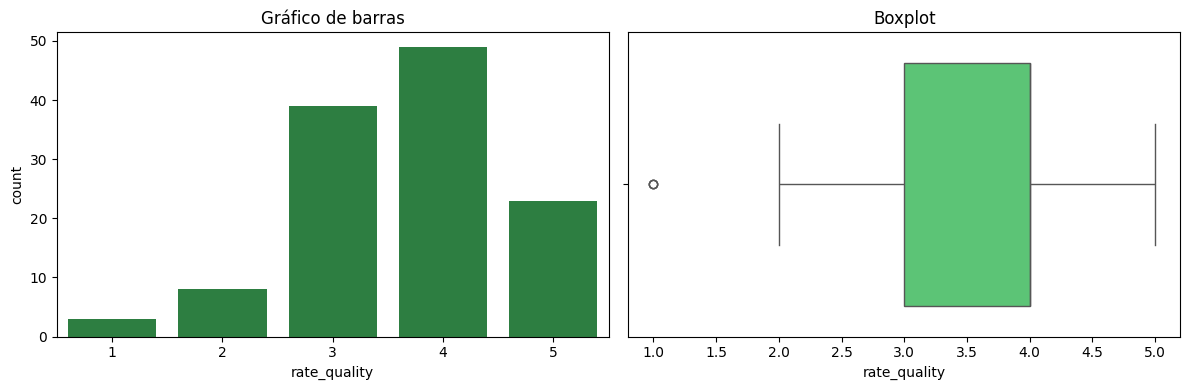

Variable: rate_price


/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


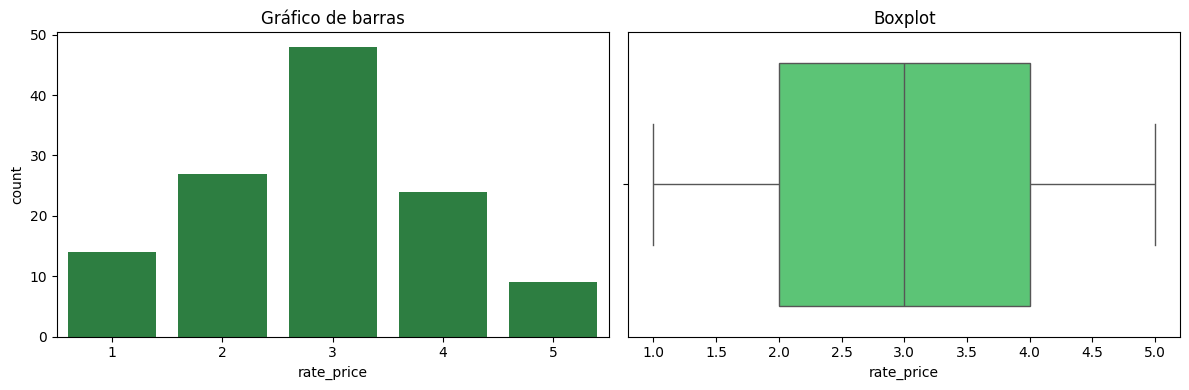

Variable: rate_promo


/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


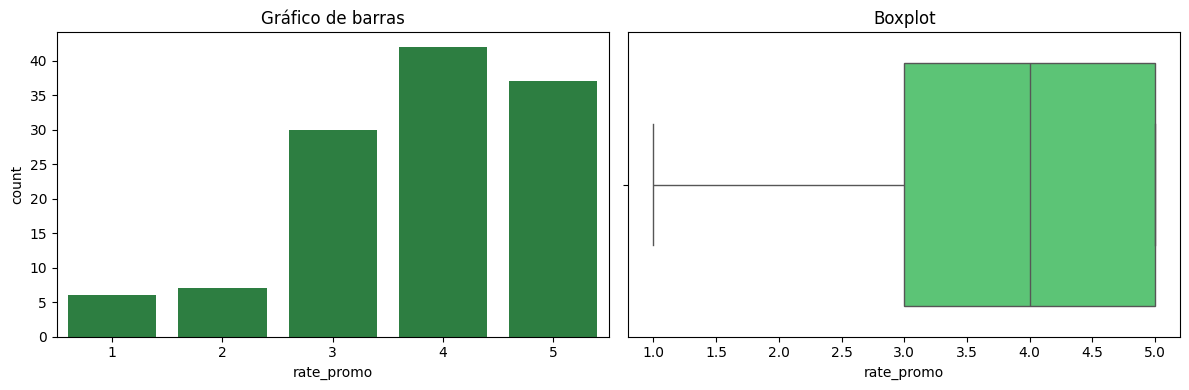

Variable: rate_ambience


/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


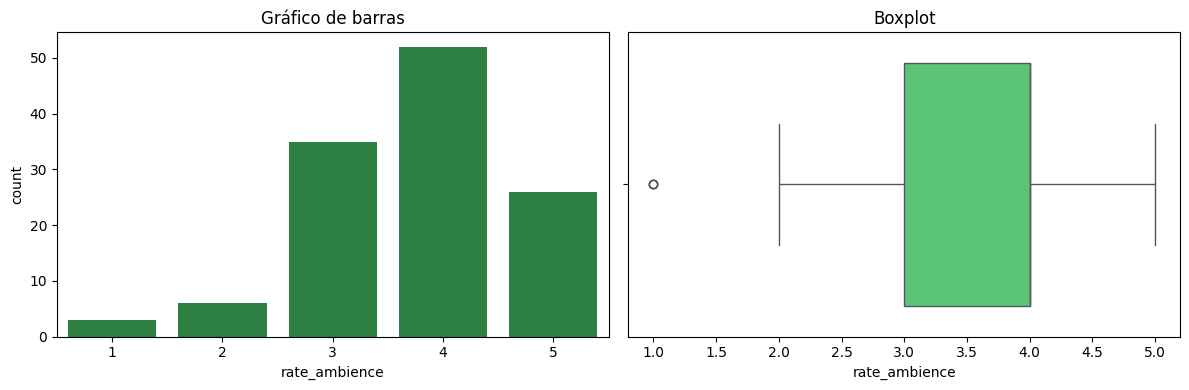

Variable: rate_wifi


/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


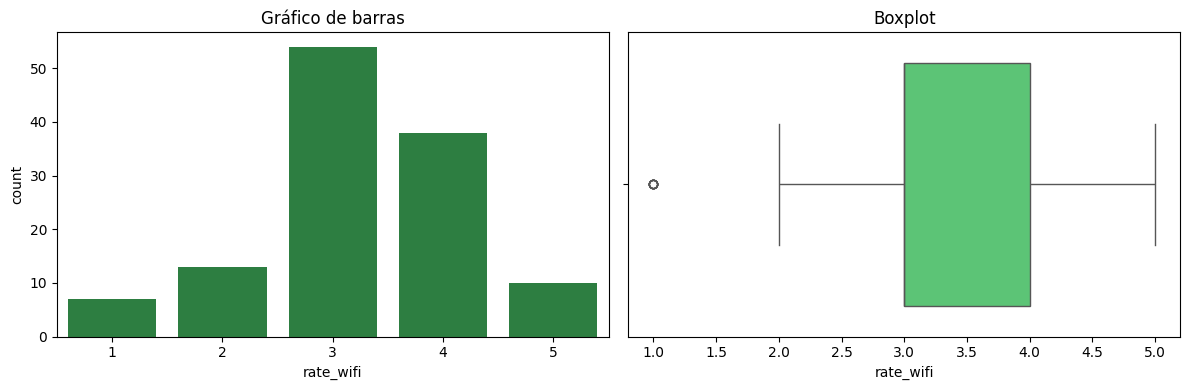

Variable: rate_service


/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


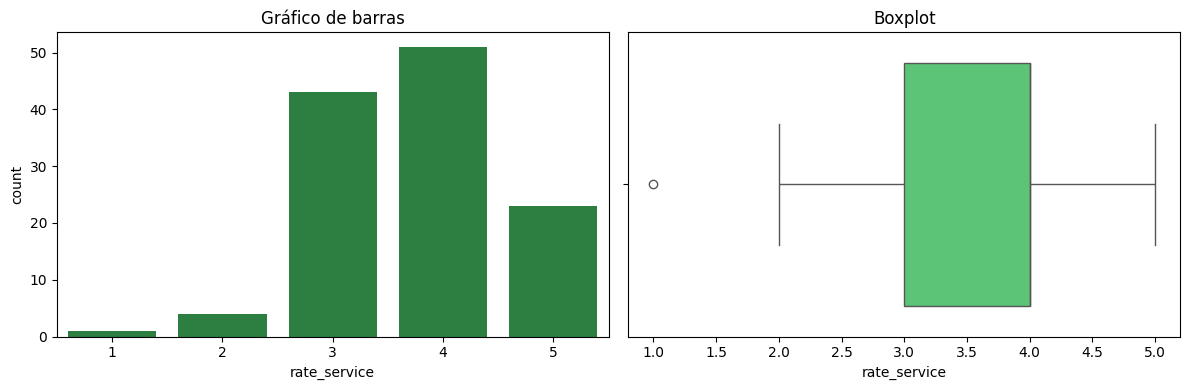

Variable: rate_meetup


/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


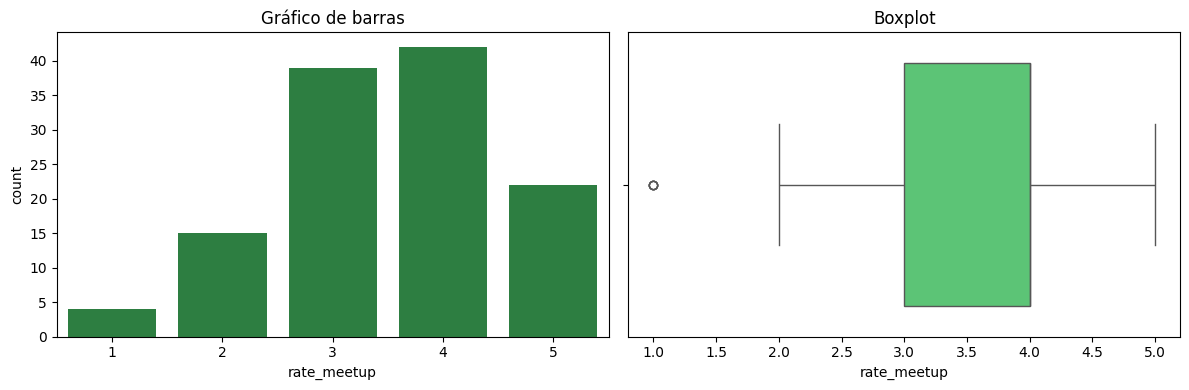

In [36]:
UnivariateIntegerAnalysis(df)

En términos generales, en todas las dimensiones evaluadas (calidad, precio, promociones, ambiente, wifi, servicio y meetups) se observa una concentración de calificaciones entre 3 y 4, lo cual sugiere un nivel de satisfacción mayoritariamente medio‐alto. Las puntuaciones extremas (1 y 5) aparecen en menor frecuencia, aunque en algunos casos pueden considerarse outliers (por ejemplo, se ven valores atípicos en 1 para wifi o en 1 para ambiente). Los boxplots confirman que la mediana de la mayoría de las variables se ubica por encima de 3, indicando una tendencia favorable en la percepción de los clientes. Sin embargo, la presencia de calificaciones bajas en ciertos aspectos implica que hay una minoría de usuarios con experiencias no tan satisfactorias, mientras que las calificaciones de 5 revelan que también existe un grupo que considera excelente alguno de los factores evaluados.

#### **Variables categóricas**

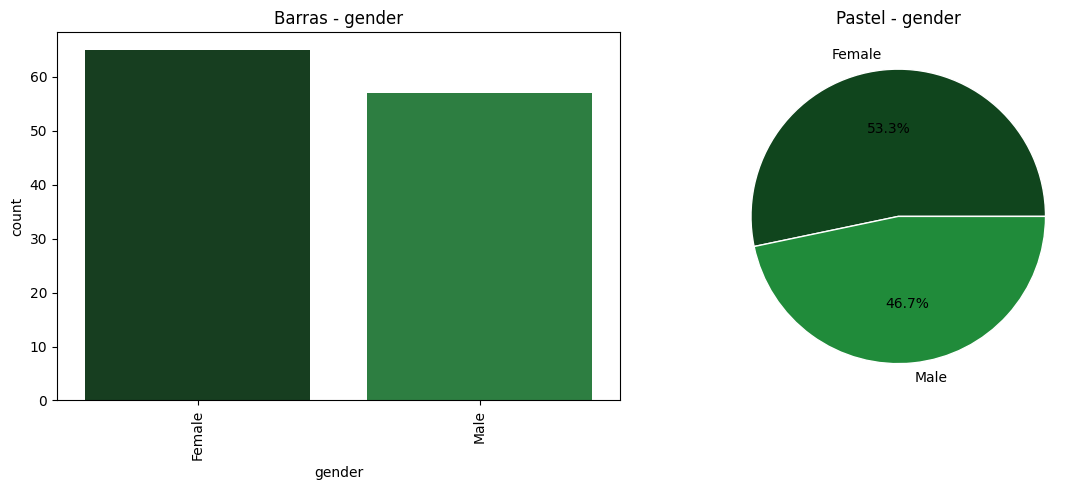

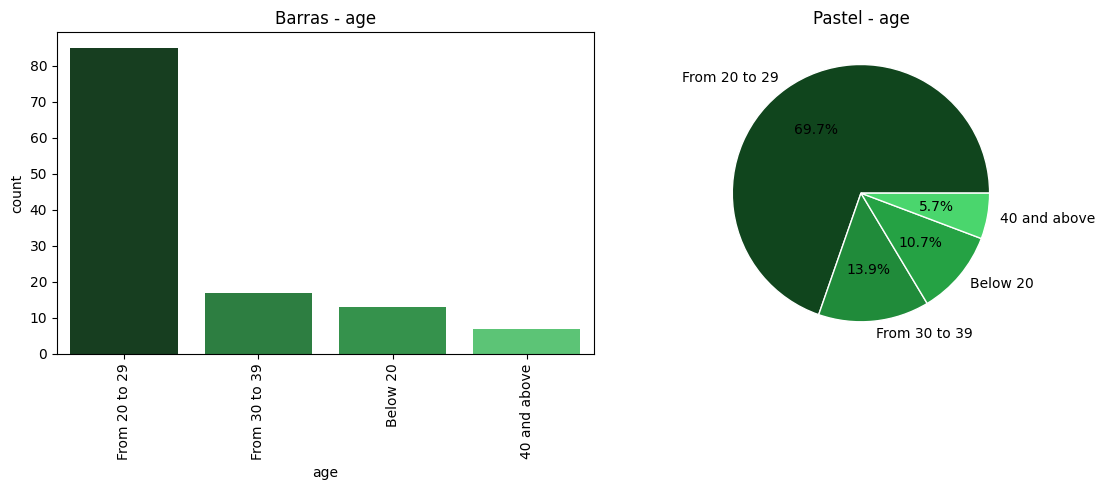

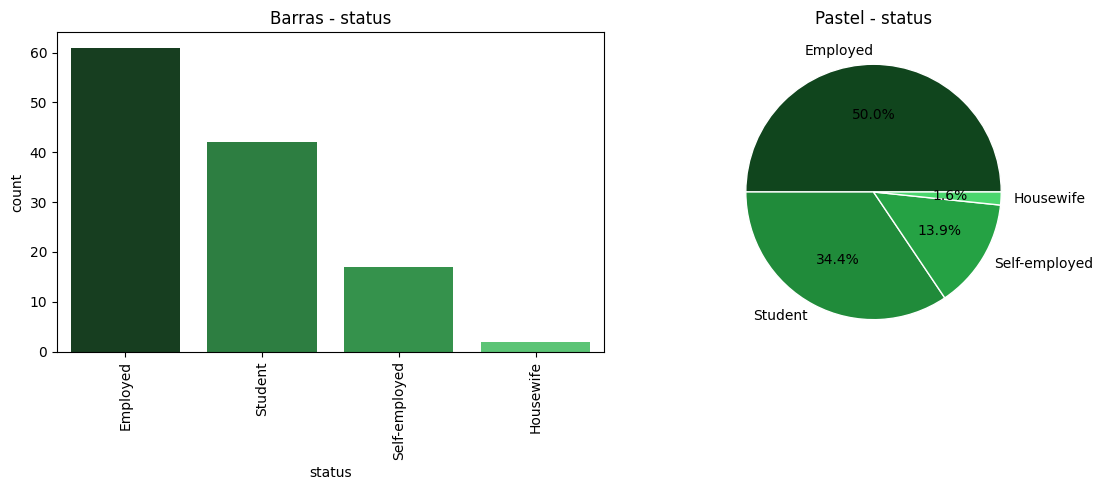

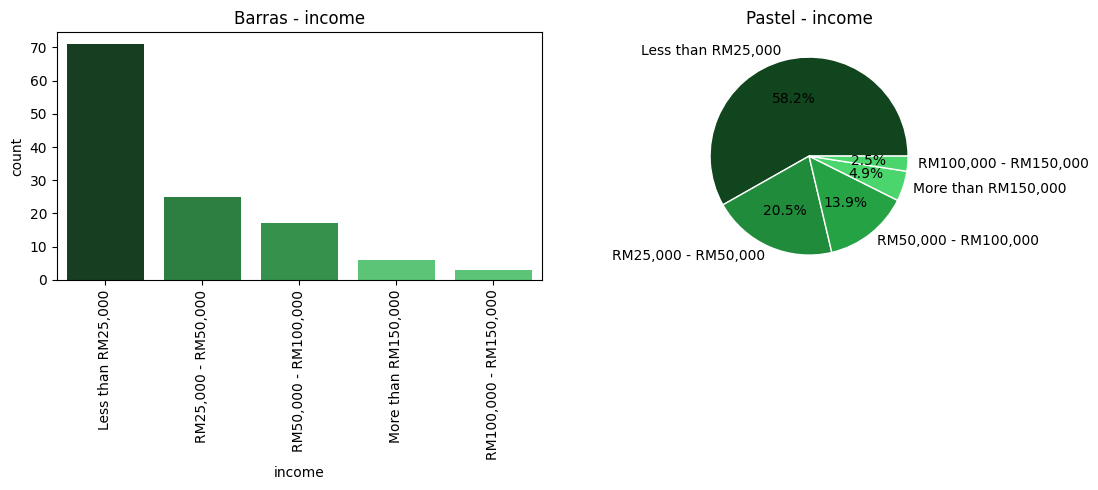

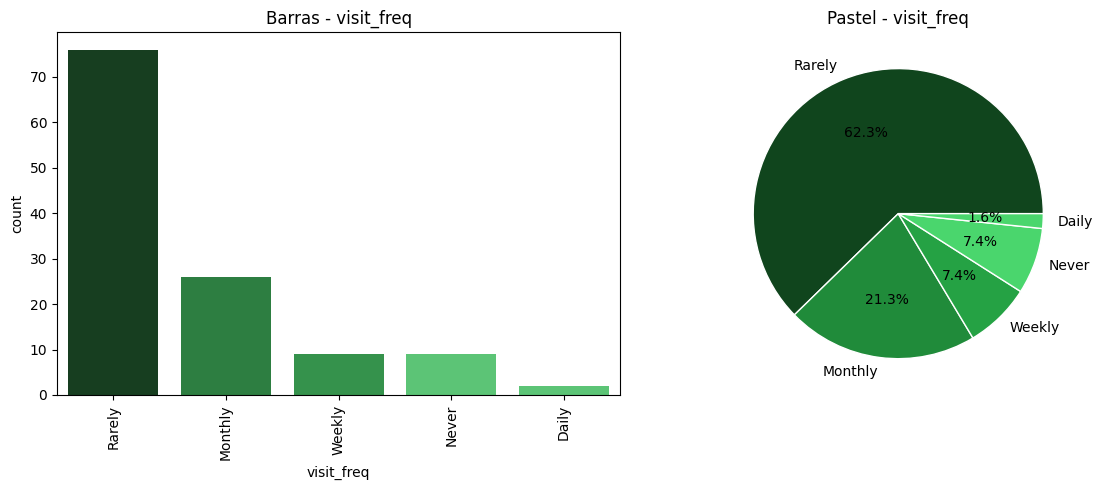

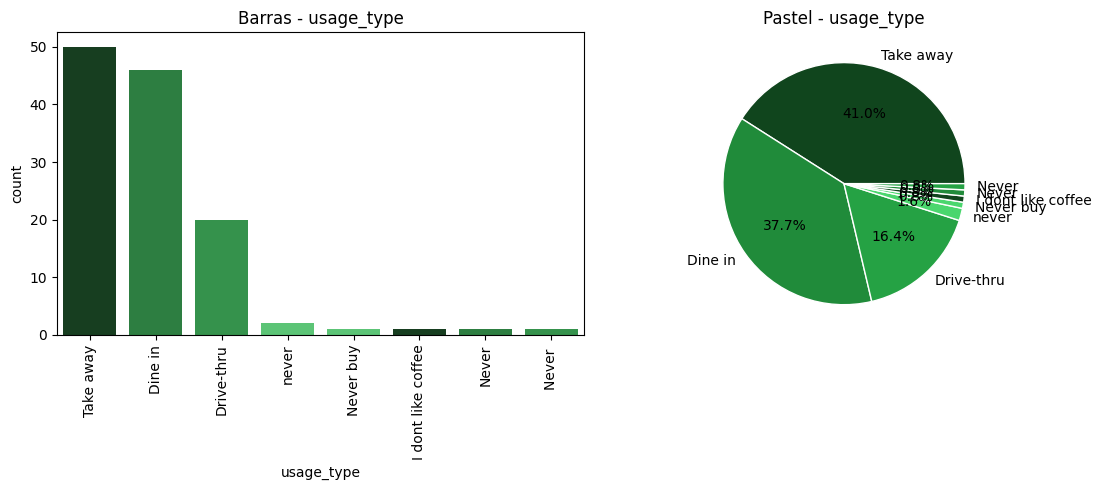

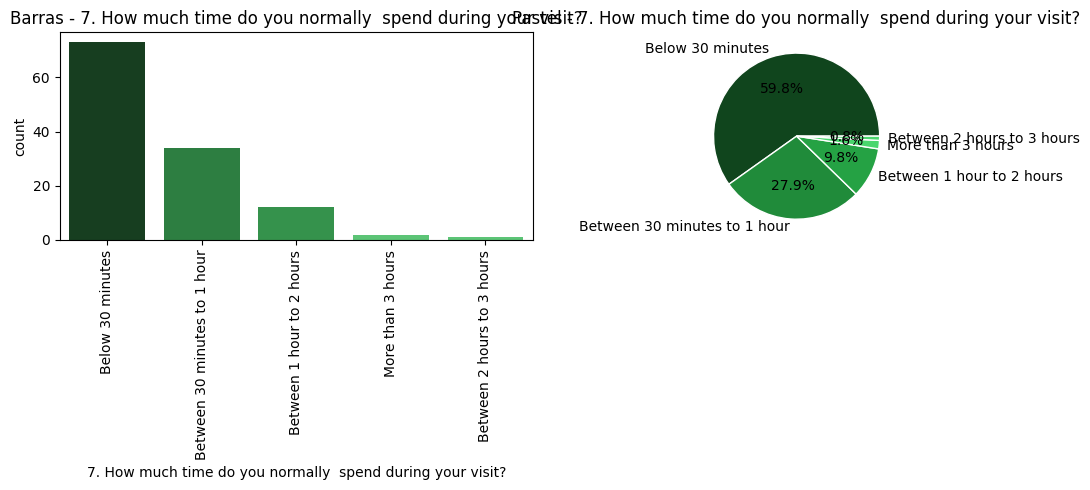

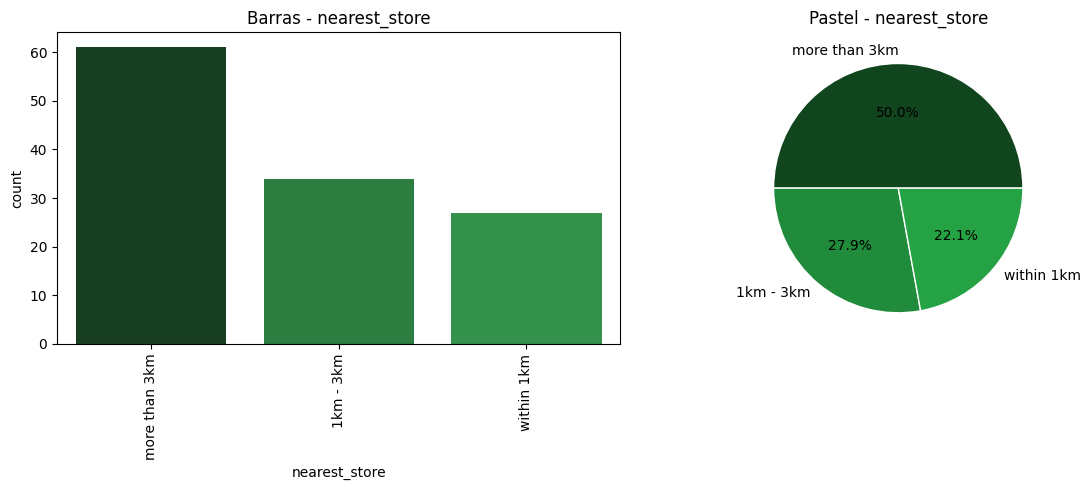

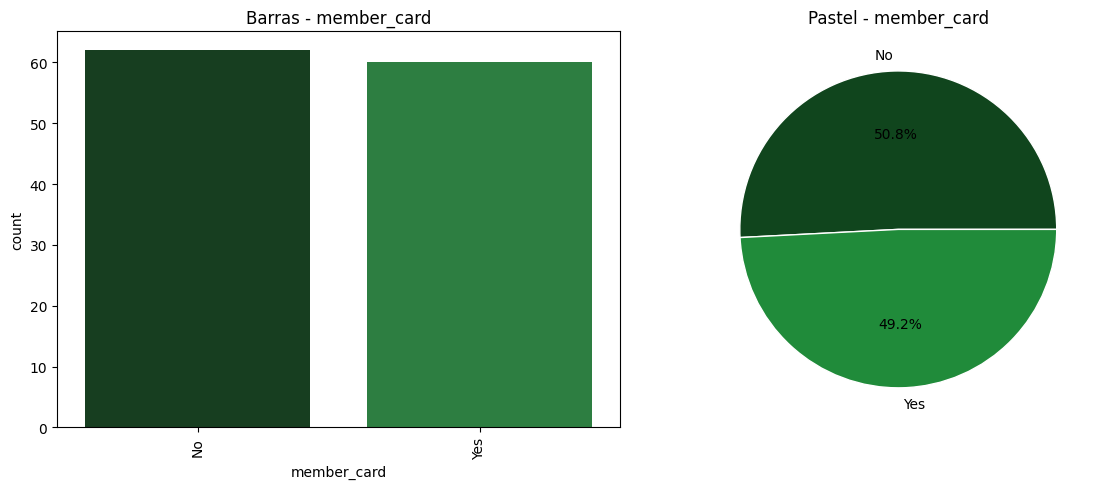

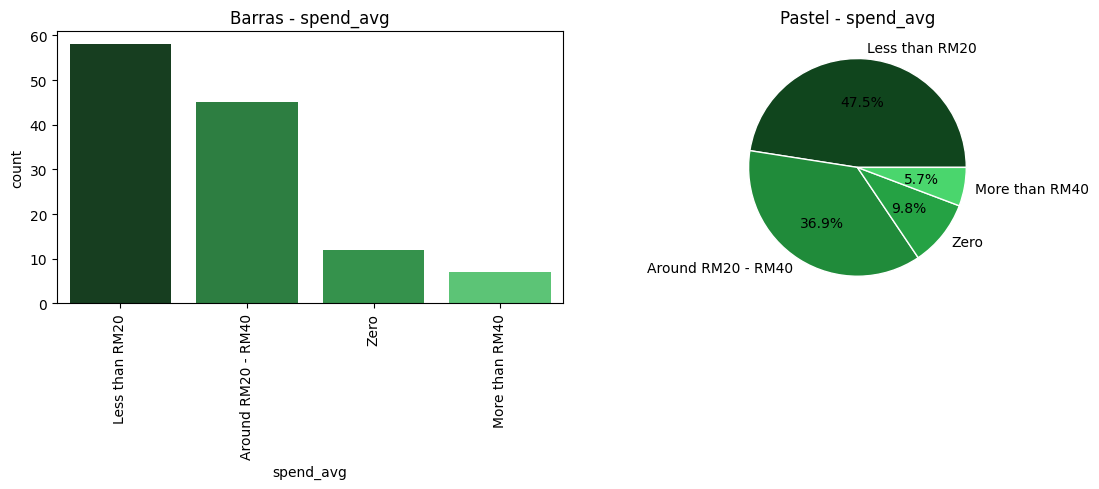

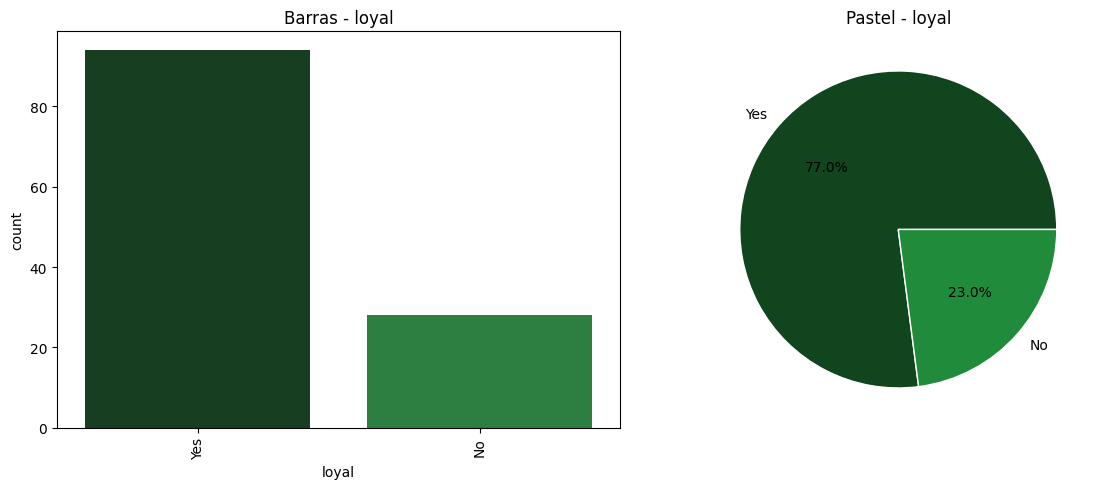

In [37]:
UnivariadoCatg(df)

## **Transformacion y Normalizacion de Datos**


Para realizar las transformaciones del dataset, es importante considerar que algunas variables presentan una gran cantidad de categorías, lo cual puede no aportar valor significativo al modelo y, por el contrario, generar ruido o complejidad innecesaria. Por ello, dichas variables deben ser evaluadas para su posible exclusión o agrupación. Asimismo, otras variables categóricas y de satisfacción pueden ser transformadas de manera estratégica para construir indicadores compuestos que capturen mejor la percepción del cliente, lo cual será útil en el modelado predictivo y en la interpretación de resultados.

In [38]:
df['spend_avg'] = df['spend_avg'].apply(CleanSpend)
df['spend_avg'].unique()
Indicadores(df)

,Timestamp,gender,age,status,income,visit_freq,usage_type,7. How much time do you normally spend during your visit?,nearest_store,member_card,...,rate_ambience,rate_wifi,rate_service,rate_meetup,promo_source,loyal,store_exp,value_score,member_card_bin,loyal_intent
0,2019/10/01 12:38:43 PM,Female,From 20 to 29,Student,"Less than RM25,000",Rarely,Dine in,Between 30 minutes to 1 hour,within 1km,Yes,...,5,4,4,3,Starbucks Website/Apps;Social Media;Emails;Dea...,Yes,4.333333,3.5,1,4.5
1,2019/10/01 12:38:54 PM,Female,From 20 to 29,Student,"Less than RM25,000",Rarely,Take away,Below 30 minutes,1km - 3km,Yes,...,4,4,5,2,Social Media;In Store displays,Yes,4.333333,3.5,1,4.5
2,2019/10/01 12:38:56 PM,Male,From 20 to 29,Employed,"Less than RM25,000",Monthly,Dine in,Between 30 minutes to 1 hour,more than 3km,Yes,...,4,4,4,3,In Store displays;Billboards,Yes,4.000000,3.5,1,4.5
3,2019/10/01 12:39:08 PM,Female,From 20 to 29,Student,"Less than RM25,000",Rarely,Take away,Below 30 minutes,more than 3km,No,...,3,3,3,3,Through friends and word of mouth,No,3.000000,1.5,0,3.0
4,2019/10/01 12:39:20 PM,Male,From 20 to 29,Student,"Less than RM25,000",Monthly,Take away,Between 30 minutes to 1 hour,1km - 3km,No,...,2,2,3,3,Starbucks Website/Apps;Social Media,Yes,2.333333,3.0,0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,2019/10/04 12:24:26 AM,Male,40 and above,Self-employed,"RM25,000 - RM50,000",Monthly,Dine in,Between 1 hour to 2 hours,1km - 3km,Yes,...,3,2,4,4,Starbucks Website/Apps;Social Media,Yes,3.000000,3.0,1,5.0
118,2019/10/04 9:30:09 AM,Male,From 20 to 29,Employed,"Less than RM25,000",Monthly,Dine in,Between 1 hour to 2 hours,1km - 3km,Yes,...,5,5,5,5,Starbucks Website/Apps;Social Media;Emails;Dea...,Yes,5.000000,5.0,1,6.0
119,2019/10/04 1:46:07 PM,Male,From 20 to 29,Student,"Less than RM25,000",Rarely,Dine in,Between 30 minutes to 1 hour,1km - 3km,No,...,3,3,3,4,Social Media;Through friends and word of mouth...,No,3.000000,2.5,0,3.5
120,2019/10/05 11:01:14 AM,Female,From 20 to 29,Employed,"Less than RM25,000",Rarely,Take away,Below 30 minutes,within 1km,No,...,4,4,4,4,Social Media;Through friends and word of mouth...,Yes,4.000000,4.0,0,4.0


In [43]:
VisualizacionInicial(df,"starbucks")


ℹ️ No se encontró columna 'Year' para análisis temporal


Ahora que no hay nulos y se construyeron indicadores se eliminaran las variables que tengan mas de 10 categoria, y las que tengan menos de 10 se van a encodear, en presencia y ausencia.

## **Modelo**

In [44]:
df=PrepararModelo(df)

In [45]:
display(df.head())

,spend_avg,rate_quality,rate_price,rate_promo,rate_ambience,rate_wifi,rate_service,rate_meetup,loyal,store_exp,...,usage_type_Never buy,usage_type_Take away,usage_type_never,7. How much time do you normally spend during your visit?_Between 1 hour to 2 hours,7. How much time do you normally spend during your visit?_Between 2 hours to 3 hours,7. How much time do you normally spend during your visit?_Between 30 minutes to 1 hour,7. How much time do you normally spend during your visit?_More than 3 hours,nearest_store_more than 3km,nearest_store_within 1km,member_card_Yes
0,19.0,4,3,5,5,4,4,3,Yes,4.333333,...,0,0,0,0,0,1,0,0,1,1
1,19.0,4,3,4,4,4,5,2,Yes,4.333333,...,0,1,0,0,0,0,0,0,0,1
2,19.0,4,3,4,4,4,4,3,Yes,4.000000,...,0,0,0,0,0,1,0,1,0,1
3,19.0,2,1,4,3,3,3,3,No,3.000000,...,0,1,0,0,0,0,0,1,0,0
4,NaN,3,3,4,2,2,3,3,Yes,2.333333,...,0,1,0,0,0,1,0,0,0,0


Ya con el dataset listo para los modelos procedemos a ajustar el modelo de regresion logistica sin Machine learning.

Dado que el dataset cuenta con únicamente 121 observaciones, al intentar realizar la limpieza y codificación de variables categóricas mediante dummies, se generaron aproximadamente **40 variables**, lo que ocasionó problemas de **convergencia** en el modelo. Por esta razón, se optó por reducir el número de variables, seleccionando únicamente aquellas que, por su naturaleza y relevancia, aportan mayor valor al modelo. Esta selección permite construir un modelo más estable, interpretable y ajustado al tamaño de la muestra.

In [49]:
vars_usar = [
    'store_exp',         # indicador de experiencia en tienda
    'value_score',       # indicador de percepción calidad/precio
    'loyal_intent',      # combinación de intención + servicio + membresía
    'rate_meetup',       # probabilidad de usar Starbucks como punto de encuentro
    'rate_service',      # atención
    'rate_quality',      # calidad percibida
    'rate_promo',        # sensibilidad a promociones
    'member_card_bin'    # si tiene tarjeta
]
def modelo_reducido(df):
    d = df.copy()
    d = d[vars_usar + ['loyal']]
    d['loyal'] = d['loyal'].apply(lambda x: 1 if 'Yes' in x else 0)
    X = d.drop(columns='loyal')
    y = d['loyal']
    X = sm.add_constant(X)
    modelo = sm.Logit(y, X).fit()
    return modelo

modelo = modelo_reducido(df)
print(modelo.summary())



Optimization terminated successfully.
         Current function value: 0.334416
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                  loyal   No. Observations:                  122
Model:                          Logit   Df Residuals:                      114
Method:                           MLE   Df Model:                            7
Date:                Thu, 27 Mar 2025   Pseudo R-squ.:                  0.3792
Time:                        12:19:30   Log-Likelihood:                -40.799
converged:                       True   LL-Null:                       -65.719
Covariance Type:            nonrobust   LLR p-value:                 1.552e-08
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -5.3194      1.888     -2.818      0.005      -9.020      -1.619
store_exp     

**Modelo Logistico clasico** *(Tome el de statsmodels porque supuse que ese era)*

### **Clusters**

In [52]:
vars_cluster = ['rate_quality', 'rate_price', 'rate_promo', 'rate_ambience',
                'rate_wifi', 'rate_service', 'rate_meetup',
                'store_exp', 'value_score', 'loyal_intent']

X = df[vars_cluster].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)


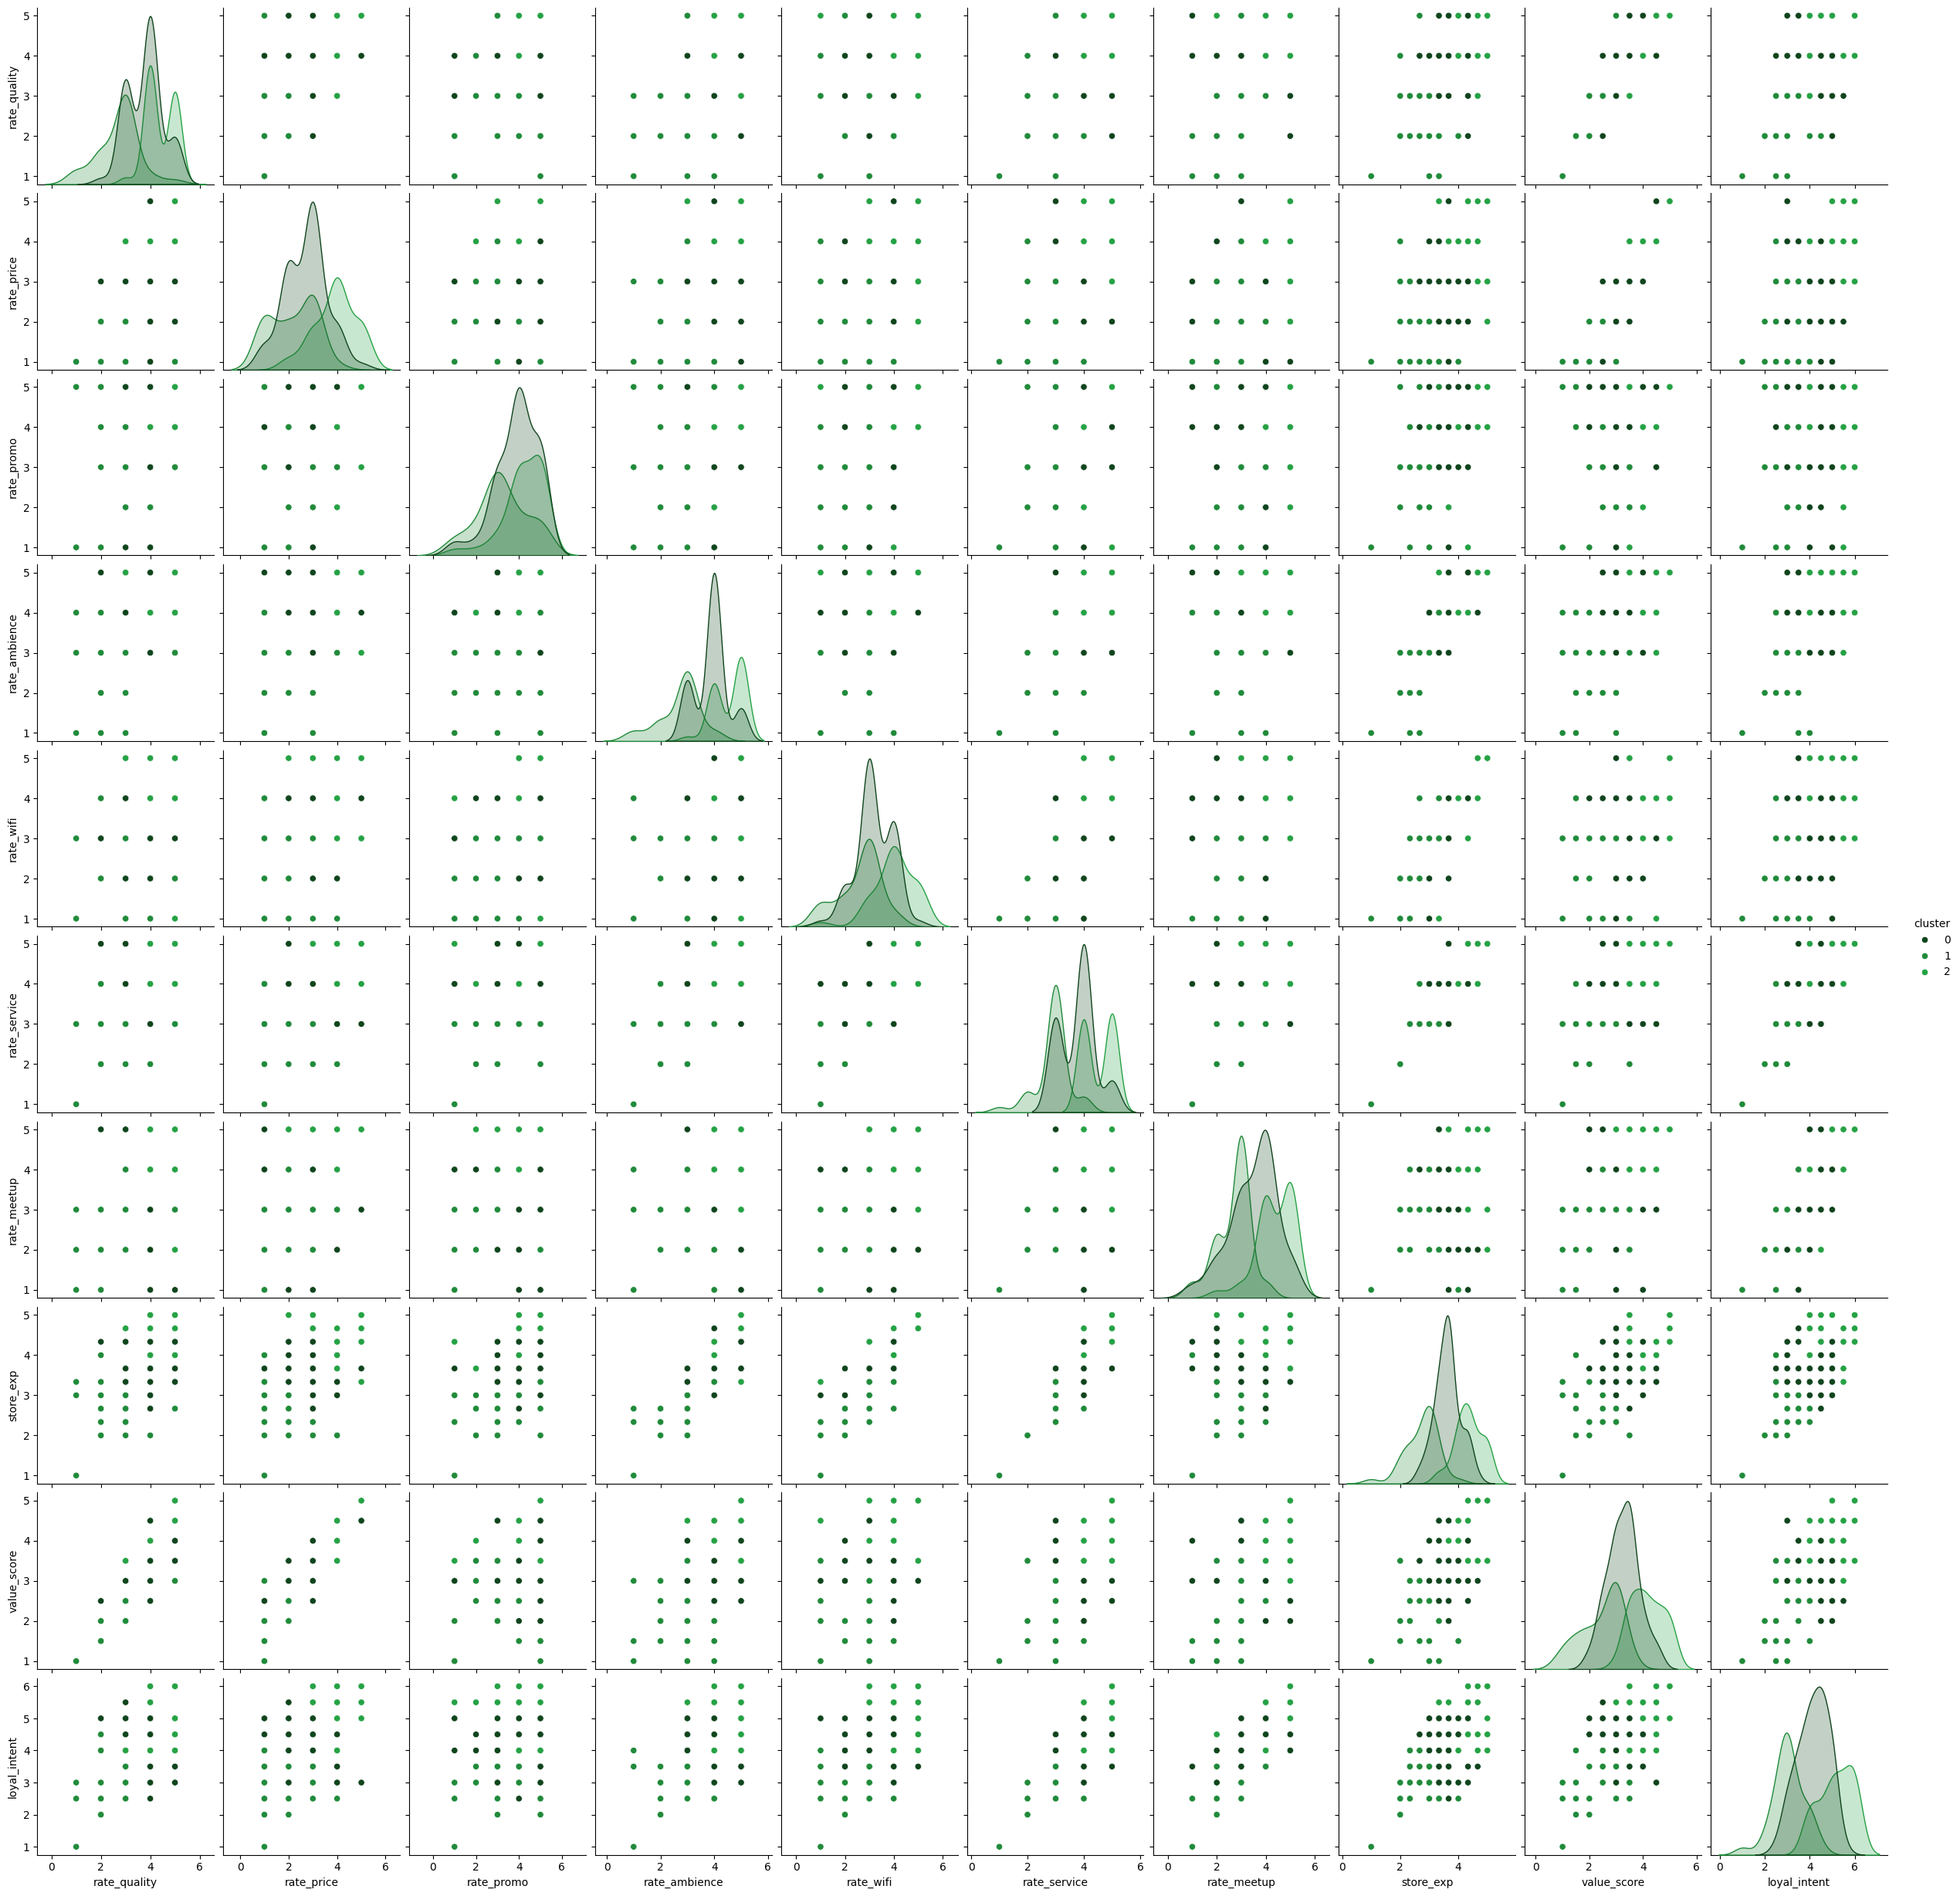

In [57]:
GreenPalette =["#10451d", "#208b3a", "#25a244"]

df['cluster'] = df['cluster'].astype(str)
sns.pairplot(df[vars_cluster + ['cluster']], hue='cluster', palette=GreenPalette)
plt.show()

**Cluster 0** – Leales satisfechos

Tiene valores altos y consistentes en:

rate_quality, rate_price, rate_promo, rate_service

También destaca en store_exp, value_score y loyal_intent

Las distribuciones se agrupan en el extremo superior derecho → Son los más satisfechos y fieles.

**Cluster 1** – Neutrales

Distribuciones concentradas en valores medios de todas las variables.

En muchas gráficas, se observan en el centro → Representan un punto intermedio.

**Cluster 2** – Críticos

Claramente agrupados en los valores más bajos:

rate_wifi, rate_service, value_score, loyal_intent

Aparecen en la zona inferior izquierda de la mayoría de los gráficos.

### **Métricas**

`value_score` representa el promedio entre la percepción de calidad del producto y el precio pagado por los clientes en Starbucks. Es decir, mide si los consumidores sienten que lo que reciben vale lo que pagan.

`value_score` es la variable más significativa del modelo de regresión logística (p = 0.001) y presenta un coeficiente positivo y alto (2.39), lo que indica que a mayor percepción de valor por parte del cliente, mayor es la probabilidad de que sea leal a Starbucks. Esta relación directa entre percepción y fidelización convierte al valor percibido en una palanca estratégica clave para impulsar decisiones de negocio enfocadas en la retención del cliente.

Aunque el modelo solo explica el 33% de la variabilidad, es un resultado positivo considerando las pocas variables y observaciones. Esto demuestra que factores como el valor percibido y la experiencia en tienda tienen peso en la fidelización. Con mejor tratamiento de datos o generación de datos sintéticos, el modelo podría volverse más robusto y preciso.

### **Comparacion con Modelos de Machine Learning**

In [58]:
df = df.drop(columns=['Timestamp'], errors='ignore')

In [60]:
# Elimina filas con valores nulos en 'loyal'
df = df.dropna(subset=['loyal'])

# Convertir etiquetas a binario
if df['loyal'].dtype == object:
    df['loyal'] = df['loyal'].map({'Yes': 1, 'No': 0})

# Elimina cualquier otra fila que tenga valores faltantes
df = df.dropna()

# Convertir variables categóricas a dummies
df = pd.get_dummies(df, drop_first=True)

# Separar variables independientes y dependiente
X = df.drop(columns='loyal')
y = df['loyal']

# Separar datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

resultados = {}

# Diccionario de modelos
modelos = {
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'Árbol de Decisión': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    resultados[nombre] = {
        'Accuracy': round(accuracy_score(y_test, y_pred), 2),
        'Precisión': round(precision_score(y_test, y_pred), 2),
        'Recall': round(recall_score(y_test, y_pred), 2),
        'F1-Score': round(f1_score(y_test, y_pred), 2)
    }

df_resultados = pd.DataFrame(resultados).T
display(df_resultados)


,Accuracy,Precisión,Recall,F1-Score
KNN,0.69,0.88,0.7,0.78
Árbol de Decisión,0.62,0.86,0.6,0.71
Random Forest,0.77,0.89,0.8,0.84


\La comparación muestra que Random Forest y el Árbol de Decisión fueron los más efectivos (F1 = 0.90), superando a KNN (F1 = 0.78). Esto demuestra que, incluso con pocas variables, se pueden construir modelos sólidos para predecir la lealtad, superando claramente al modelo de regresión logística que explicaba solo el 37% de la varianza.









## **Conclusión**

Los análisis permitieron identificar tres perfiles diferenciados de clientes según su percepción de valor, experiencia en tienda y nivel de fidelidad. Estos grupos revelan comportamientos y prioridades distintas que Starbucks puede aprovechar para personalizar sus estrategias. Por ejemplo, un clúster mostró alta valoración del servicio y fuerte intención de fidelización, lo que lo convierte en un público ideal para programas de membresía o promociones exclusivas.

Además, al evaluar distintos modelos predictivos, se encontró que el Árbol de Decisión y el Random Forest fueron los más precisos y balanceados, con un F1-Score del 90%. Esto sugiere que Starbucks debería apoyarse en estos modelos para identificar clientes leales de forma más efectiva y tomar decisiones basadas en datos para fidelizar a sus segmentos más valiosos.

### **No convergeencia del modelo logístico con todos los dummies**

In [ ]:
modelo = modelo_limpio(df)
print(modelo.summary())

         Current function value: 0.014716
         Iterations: 100
         Function evaluations: 102
         Gradient evaluations: 102
                           Logit Regression Results                           
Dep. Variable:                  loyal   No. Observations:                  122
Model:                          Logit   Df Residuals:                       85
Method:                           MLE   Df Model:                           36
Date:                Thu, 27 Mar 2025   Pseudo R-squ.:                  0.9727
Time:                        10:54:45   Log-Likelihood:                -1.7954
converged:                      False   LL-Null:                       -65.719
Covariance Type:            nonrobust   LLR p-value:                 3.270e-12
                                                                                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

/usr/local/lib/python3.11/dist-packages/scipy/optimize/_optimize.py:1291: OptimizeWarning:

Maximum number of iterations has been exceeded.

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning:

Inverting hessian failed, no bse or cov_params available

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

